In [1]:
import qbiome
from qbiome.data_formatter import DataFormatter
from qbiome.quantizer import Quantizer
from qbiome.qnet_orchestrator import QnetOrchestrator
from qbiome.forecaster import Forecaster
from qbiome.hypothesis import Hypothesis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight")
from qbiome.qutil import qsmooth

In [6]:
# File path to your merged CSV file
DF_pop_file_path = "example_data/microprophet/microbiome_wide_data_week_60-90_pred.csv"  # update with actual path if needed

# Read the CSV into a DataFrame
DF = pd.read_csv(DF_pop_file_path,keep_default_na=False)

DF = DF.melt(
    id_vars=['subject_id', 'time'],  # keep these columns as identifiers
    var_name='variable',             # new column name for former column headers
    value_name='value'               # new column name for the values
)

# Optionally, rename 'time' to 'week' if that's more appropriate
DF = DF.rename(columns={'time': 'week'})


# Reorder columns if needed
DF = DF[['subject_id', 'variable', 'value', 'week']]

# Display result
print(DF.head())

  subject_id    variable     value  week
0   Budapest  Acidovorax  0.027286    69
1   Budapest  Acidovorax  0.022299    70
2   Budapest  Acidovorax  0.021641    71
3   Budapest  Acidovorax  0.022044    72
4   Budapest  Acidovorax  0.026956    73


In [3]:
# File path to your merged CSV file
DF_data_file_path = "example_data/microprophet/microbiome_wide_data_week_60-90_labels.csv"  # update with actual path if needed

# Read the CSV into a DataFrame
data = pd.read_csv(DF_data_file_path,keep_default_na=False)

In [7]:


data = data.melt(
    id_vars=['subject_id', 'time'],  # keep these columns as identifiers
    var_name='variable',             # new column name for former column headers
    value_name='value'               # new column name for the values
)

# Optionally, rename 'time' to 'week' if that's more appropriate
data = data.rename(columns={'time': 'week'})


# Reorder columns if needed
data = data[['subject_id', 'variable', 'value', 'week']]

# Display result
print(data.head())

  subject_id    variable     value  week
0   Budapest  Acidovorax  0.109461    69
1   Budapest  Acidovorax  0.000000    70
2   Budapest  Acidovorax  0.000000    71
3   Budapest  Acidovorax  0.000000    72
4   Budapest  Acidovorax  0.066955    73


In [9]:
DF_pop = DF.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()
DF_data = data.groupby(["variable", "week"]).mean(numeric_only=True).reset_index()

DF_pop_smooth = qsmooth(
    DF_pop,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)

# DF_data_smooth
DF_data_smooth = qsmooth(
    DF_data,
    index="week",
    columns="variable",
    normalize=False,
    alpha=0.99,
    interpolate=False,
    lowess_fraction=0.3,
)


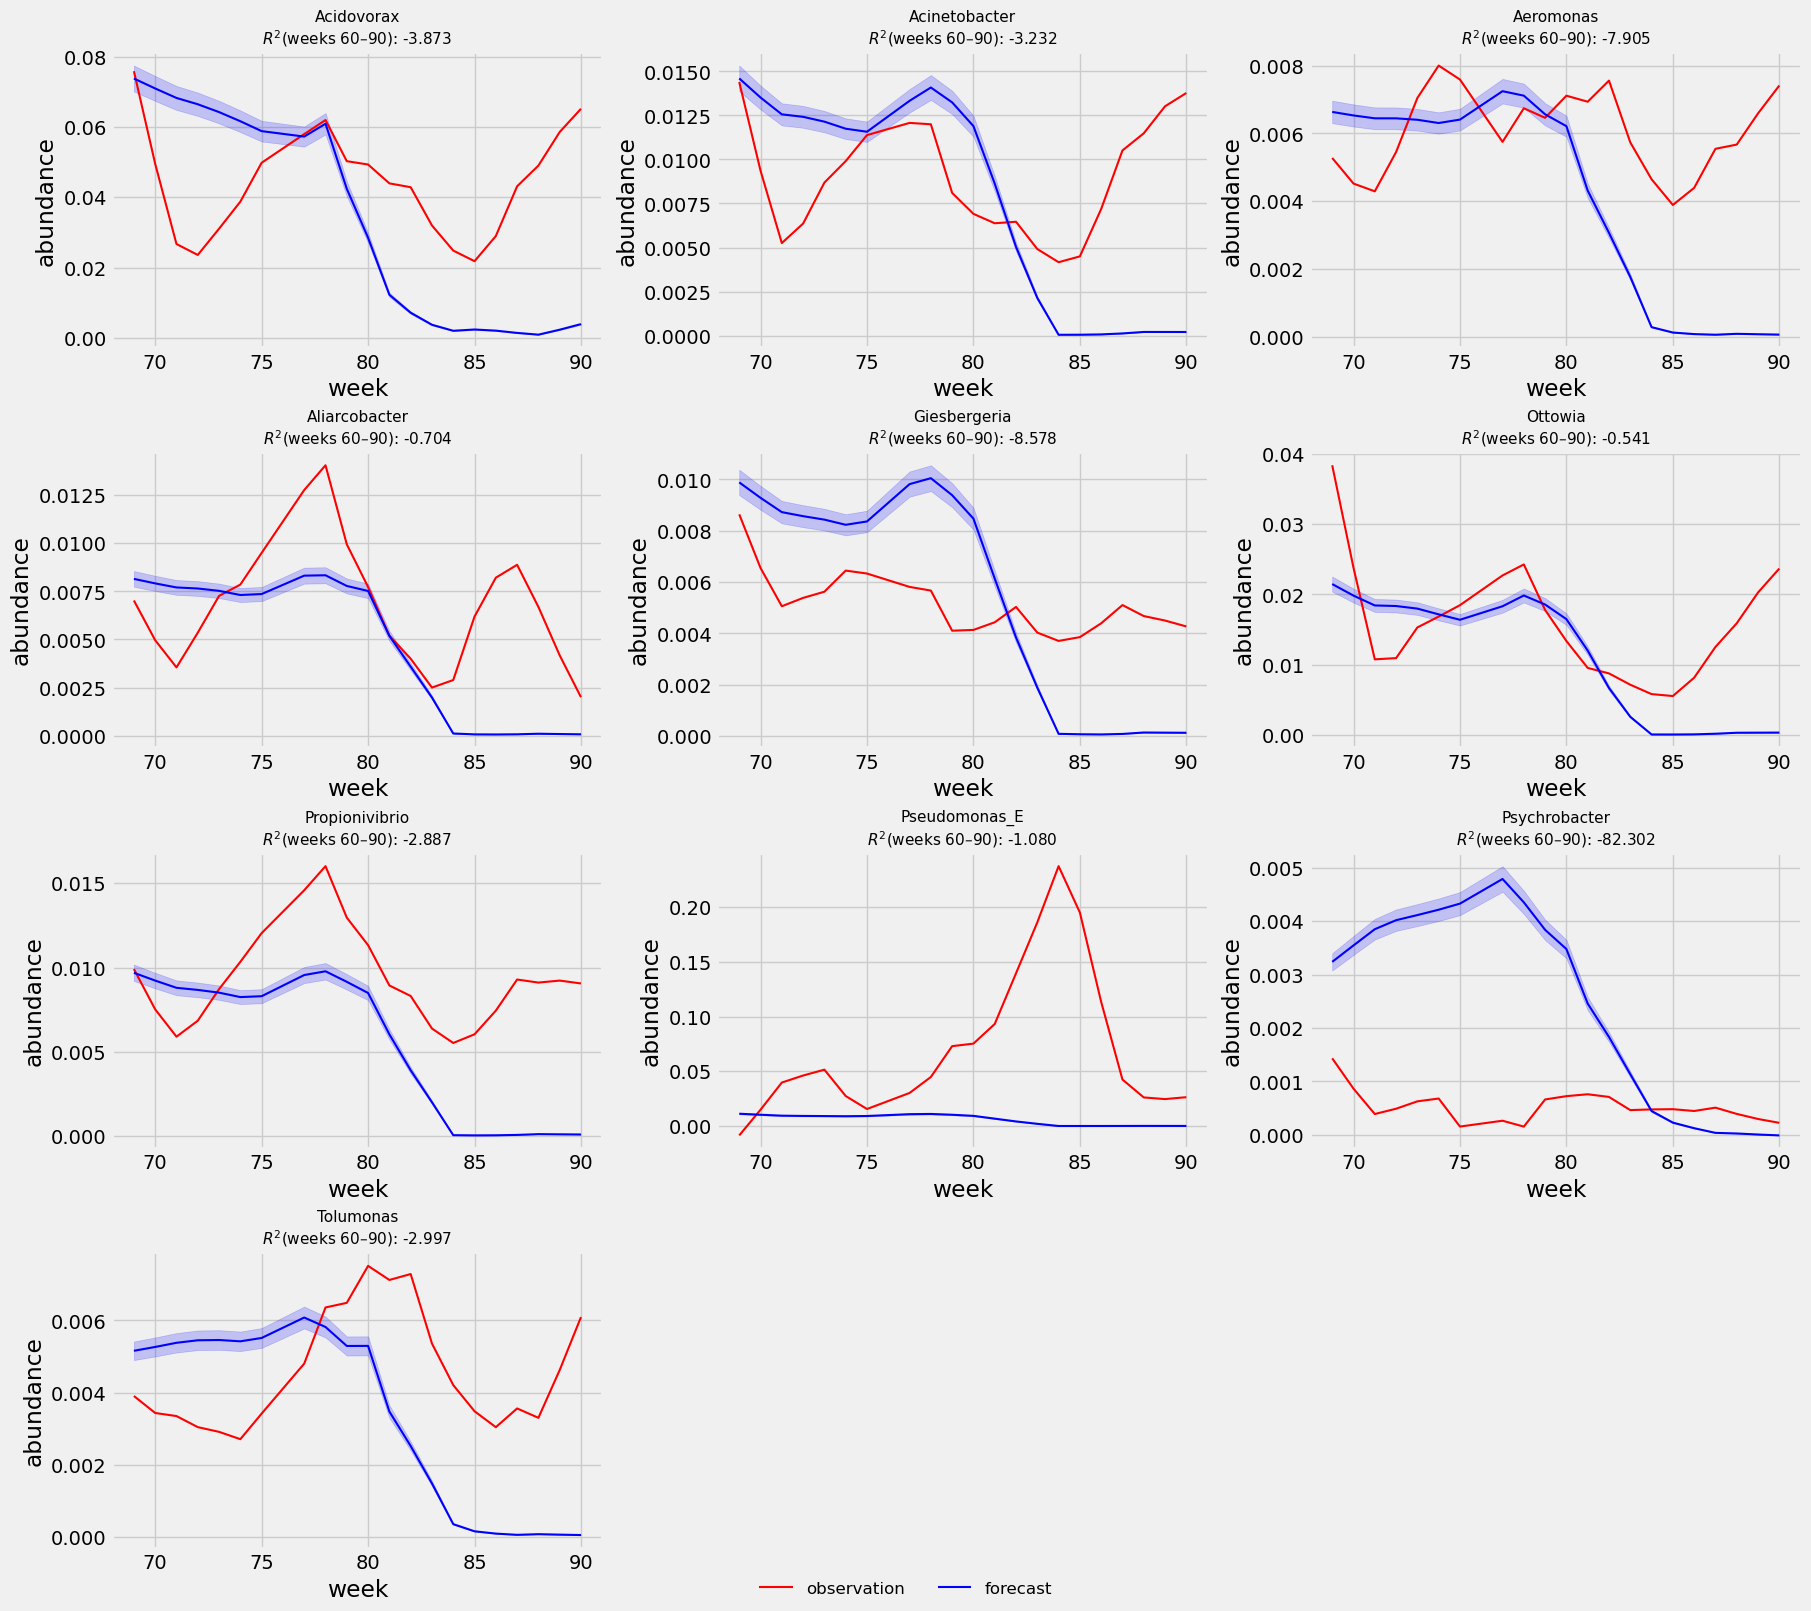

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Explicitly specify the taxa to include
selected_taxa = [
    "Acidovorax", "Acinetobacter", "Aeromonas", "Aliarcobacter", "Giesbergeria",
    "Ottowia", "Propionivibrio", "Pseudomonas_E", "Psychrobacter", "Tolumonas"
]

# Week vector
weeks = DF_data_smooth['week'] if 'week' in DF_data_smooth.columns else DF_data_smooth.index

# Subplot layout
ncols = 3
nrows = (len(selected_taxa) + ncols - 1) // ncols

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows), constrained_layout=True)
axs = axs.flatten()

# Plotting loop
for i, taxon in enumerate(selected_taxa):
    ax = axs[i]

    obs = DF_data_smooth[taxon].values
    pred = DF_pop_smooth[taxon].values

    r2_all = r2_score(obs, pred)

    ax.plot(weeks, obs, label="observation", color="red", linewidth=1.5)
    ax.plot(weeks, pred, label="forecast", color="blue", linewidth=1.5)

    ax.fill_between(weeks, pred * 0.95, pred * 1.05, color="blue", alpha=0.2)

    ax.set_title(f"{taxon}\n$R^2$(weeks 60–90): {r2_all:.3f}", fontsize=11)
    ax.set_xlabel("week")
    ax.set_ylabel("abundance")

# Remove any unused axes
for j in range(len(selected_taxa), len(axs)):
    fig.delaxes(axs[j])

# Common legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=12, frameon=False)

plt.subplots_adjust(bottom=0.1)
plt.show()
